In [1]:
import numpy as np
import matplotlib.pyplot as plt

from lightmatter.fdtd import run_simulation
from lightmatter.fdtd import MaterialParamsTD,PulseParams, FDTDParams
from lightmatter.io import make_fdtd_gif, plot_fdtd_frame, save_simulation_run, load_simulation_run

# Units, time = ps => frequency = THz, 
# mass = m_e, q = e, x = A
# => E = 5.686e2 V / m
# unit_M = 9.109e-31
# unit_Q = 1.602e-19
unit_F = 1e12
unit_T = 1e-12
unit_L = 1e-10
# unit_E = 5.686e2
c0  = 3.0e6 # in code units
# mu0 = 4e-7 * np.pi
# eps0 = 1.0 / (mu0 * c0**2)
# Z0 = np.sqrt(mu0 / eps0)

In [2]:
# Grid + time
L = 60 * 1e4 # A
dz= 10.0 # A
Nz = int(L/dz)
dt = 0.99 * dz / c0       # CFL stability for 1D, ~ 3 fs

# Source
src_pos = 10.0 * 1e4
src_i = int(np.round(src_pos/dz))

# metal film
x_0 = L/2.0 # place at center
thickness = 500.0 # = 50 nm

metal_cells = int(np.round(thickness / dz))
metal_center_i = int(np.round(x_0 / dz))
metal_i0 = metal_center_i - metal_cells // 2
metal_i1 = metal_i0 + metal_cells

#probes
probe_r_pos = x_0 - thickness / 2.0 - 1.0 * 1e4
probe_t_pos = x_0 + thickness / 2.0 + 1.0 * 1e4
probe_r_i = int(np.round(probe_r_pos/dz))           # left-side probe (reflected)
probe_t_i = int(np.round(probe_t_pos/dz))           # right-side probe (transmitted)

T_estimate = np.abs(src_pos - probe_t_pos) / c0 * 2.0
T = np.round(T_estimate + 0.005, 3) #ps
Nt = int(T/dt)

simulation_params_withfilm = FDTDParams(
    Nz=Nz,
    Nt=Nt,
    dz= 10.0, # A
    dt=dt,
    src_i=src_i,
    probe_t_i=probe_t_i,
    probe_r_i=probe_r_i,
    metal_i0=metal_i0,
    metal_i1=metal_i1,
    snap_every= 100,  # 0 disables snapshots
)

simulation_params_nofilm = FDTDParams(
    Nz=Nz,
    Nt=Nt,
    dz= 10.0, # A
    dt=dt,
    src_i=src_i,
    probe_t_i=probe_t_i,
    probe_r_i=probe_r_i,
    metal_i0=metal_i0,
    metal_i1=metal_i0, # make metal thickness=0.0
    snap_every= 100,  # 0 disables snapshots
)

E0_VA = 0.1 # E0 in V / A
E0 = E0_VA * 1.7588e7 # in code units
f0 = 390.0    # THz
tau = 0.004 * 0.5 # 4 fs ; short pulse
t0 = 5*tau
pulse = PulseParams(E0=E0, f0=f0, t0=t0, tau=tau, phase=0.0)

material = MaterialParamsTD.from_static(
    Nt=simulation_params_withfilm.Nt,
    omega_D=2*np.pi*2113.6, 
    gamma_D=2.0*np.pi*15.92,
    omega_L=2.0*np.pi*650.07, 
    gamma_L=2.0*np.pi*104.86,
    del_eps=1.09, 
    eps_inf=5.9673,
)



## Simulation runs

In [ ]:
E_t_withfilm, E_r_withfilm, snaps_t_withfilm, snaps_E_withfilm = run_simulation(simulation_params_withfilm, pulse, material)
E_t_nofilm, E_r_nofilm, snaps_t_nofilm, snaps_E_nofilm = run_simulation(simulation_params_nofilm, pulse, material)

In [4]:
E_t_nofilm, E_r_nofilm, snaps_t_nofilm, snaps_E_nofilm = run_simulation(simulation_params_nofilm, pulse, material)

In [5]:
save_simulation_run(
    folder="../output/trial1/with_film",
    params=simulation_params_withfilm, 
    pulse=pulse,             
    material=material,           
    E_t=E_t_withfilm,
    E_r=E_r_withfilm,
    snaps_t=snaps_t_withfilm,
    snaps_E=snaps_E_withfilm,
)

save_simulation_run(
    folder="../output/trial1/nofilm",
    params=simulation_params_nofilm, 
    pulse=pulse,             
    material=material,           
    E_t=E_t_nofilm,
    E_r=E_r_nofilm,
    snaps_t=snaps_t_nofilm,
    snaps_E=snaps_E_nofilm,
)

Simulation saved to: ../output/trial1/with_film
Simulation saved to: ../output/trial1/nofilm


## Old

In [6]:
def omega_L_exp(t,omega0,alpha):
    return omega0 * np.exp(alpha*t)

def omega_D_exp(t,omega0,alpha):
    return omega0 * np.exp(alpha*t)

## Retrieve stored data

In [6]:
result_nofilm = load_simulation_run("../output/trial1/nofilm")
result_withfilm = load_simulation_run("../output/trial1/with_film")

E_t_withfilm = result_withfilm["E_t"]
E_t_nofilm = result_nofilm["E_t"]

## Calculate refractive index

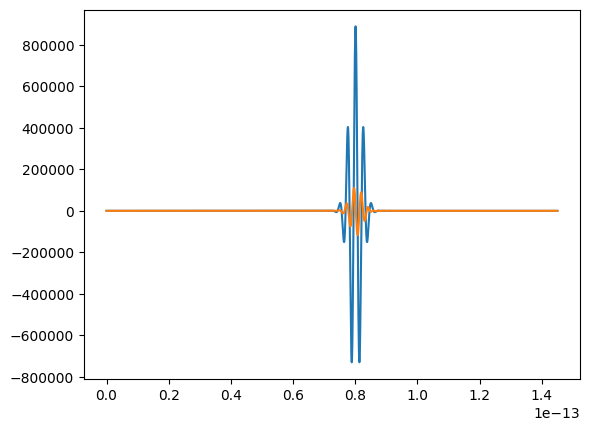

In [8]:
t_ax = np.linspace(0.0,T,Nt) * unit_T

plt.plot(t_ax,E_t_nofilm)
plt.plot(t_ax,E_t_withfilm)

In [9]:
from lightmatter.fdtd import retrieve_nk_from_time_traces


w_fit, n_fit, k_fit, t_meas_fit, t_model_fit, good = retrieve_nk_from_time_traces(E_transmitted=E_t_withfilm,
                                                                                  E_incident=E_t_nofilm,
                                                                                  t_ax=t_ax,
                                                                                  d=thickness*unit_L)

In [13]:
t_meas_fit

array([0.99592247+0.09021328j, 0.99558999+0.09381139j,
       0.99524451+0.09740828j, 0.99488603+0.10100389j,
       0.99451456+0.10459819j, 0.99413011+0.10819112j,
       0.99373268+0.11178264j, 0.99332227+0.1153727j ,
       0.9928989 +0.11896125j, 0.99246256+0.12254825j,
       0.99201326+0.12613365j, 0.991551  +0.12971741j,
       0.99107581+0.13329946j, 0.99058767+0.13687978j,
       0.99008659+0.14045831j, 0.98957259+0.14403501j,
       0.98904567+0.14760983j, 0.98850584+0.15118272j,
       0.98795309+0.15475363j, 0.98738745+0.15832253j,
       0.98680892+0.16188936j, 0.9862175 +0.16545407j,
       0.9856132 +0.16901662j, 0.98499604+0.17257697j,
       0.98436601+0.17613506j, 0.98372313+0.17969086j,
       0.98306741+0.1832443j , 0.98239885+0.18679536j,
       0.98171746+0.19034397j, 0.98102326+0.1938901j ,
       0.98031624+0.1974337j , 0.97959643+0.20097472j,
       0.97886382+0.20451312j, 0.97811844+0.20804885j,
       0.97736028+0.21158186j, 0.97658936+0.2151121j ,
       0.9

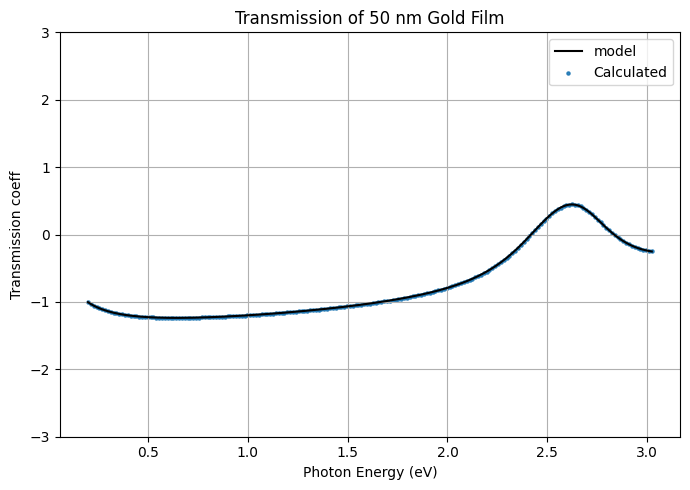

In [ ]:
phot_ev = w_fit/(2.0*np.pi) * 4.136e-15 # convert to eV -> freq * h/e

# plt.plot(phot_ev,np.abs(t_model_fit))
# plt.plot(phot_ev,np.abs(t_meas_fit))

plt.figure(figsize=(7,5))
plt.plot(phot_ev,np.angle(t_model_fit),label="model",color="black")
plt.scatter(phot_ev,np.angle(t_meas_fit),s=5.0,label="Calculated", alpha = 0.9)

plt.xlabel('Photon Energy (eV)')
plt.ylabel('Transmission coeff')
plt.title('Transmission of 50 nm Gold Film')
plt.grid(True)
# plt.xlim((0.5,3.5))
plt.ylim((-3,3))
plt.legend()
plt.tight_layout()
plt.show()



# plt.plot(phot_ev,n_fit)
# plt.plot(phot_ev,k_fit)

In [ ]:
# -----------------------------
# Physical constants
# -----------------------------
c0_SI = 2.9979e8          # m/s
h_eVs = 4.135667696e-15     # Planck constant (eV·s)

# -----------------------------
# Gold optical constants (from Johnson and Christy, 1972)
# -----------------------------
# Photon energy in eV
E_eV = np.array([
    0.64, 0.77, 0.89, 1.02, 1.14, 1.26, 1.39, 1.51, 1.64, 1.76,
    1.88, 2.01, 2.13, 2.26, 2.38, 2.50, 2.63, 2.75, 2.88, 3.00,
    3.12, 3.25, 3.37, 3.50, 3.62, 3.74, 3.87, 3.99, 4.12
])

# Real part (n)
n_gold = np.array([
    0.92, 0.56, 0.43, 0.35, 0.27, 0.22, 0.17, 0.16, 0.14, 0.13,
    0.14, 0.21, 0.29, 0.43, 0.62, 1.04, 1.31, 1.38, 1.45, 1.46,
    1.47, 1.46, 1.48, 1.50, 1.48, 1.48, 1.54, 1.53, 1.53
])

# Imaginary part (k)
k_gold = np.array([
    13.78, 11.21, 9.519, 8.145, 7.150, 6.350, 5.663, 5.083, 4.542, 4.103,
    3.697, 3.272, 2.863, 2.455, 2.081, 1.833, 1.849, 1.914, 1.948, 1.958,
    1.952, 1.933, 1.895, 1.866, 1.871, 1.883, 1.898, 1.893, 1.889
])


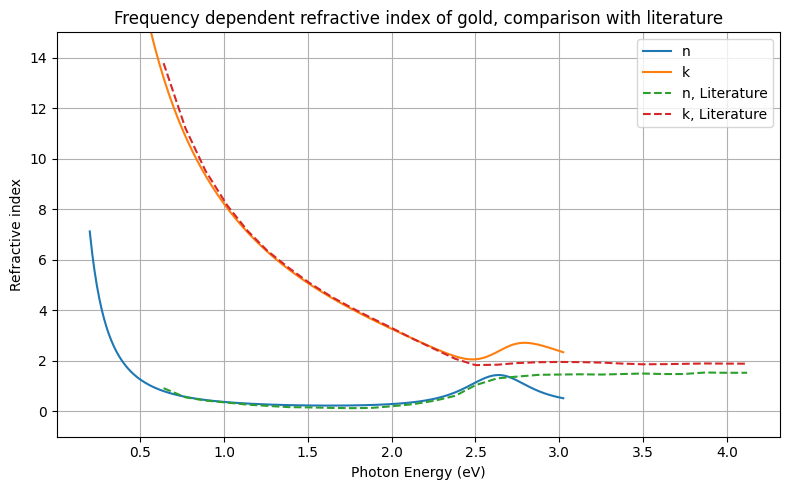

In [47]:
plt.figure(figsize=(8,5))
plt.plot(phot_ev,n_fit,label="n")
plt.plot(phot_ev,k_fit,label="k")
plt.plot(E_eV, n_gold, label='n, Literature',linestyle="--")
plt.plot(E_eV, k_gold, label='k, Literature',linestyle="--")

plt.xlabel('Photon Energy (eV)')
plt.ylabel('Refractive index')
plt.title('Frequency dependent refractive index of gold, comparison with literature')
plt.grid(True)
# plt.xlim((0.5,3.5))
plt.ylim((-1.0,15.0))
plt.legend()
plt.tight_layout()
plt.show()


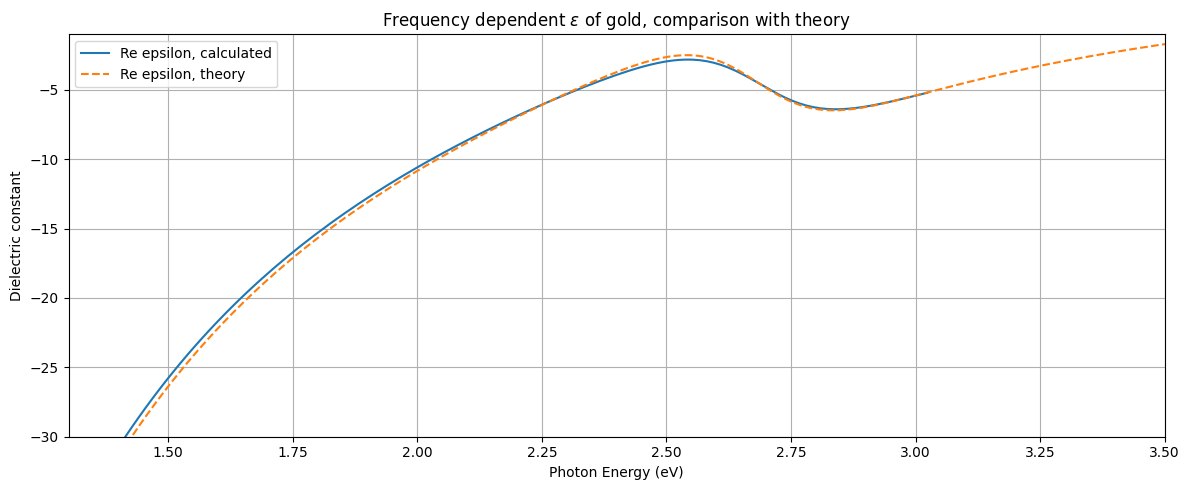

In [58]:
# dielectric constant
from lightmatter.utils import epsilon_analytical_drude_lorentz

epsilon_calculated = np.power(n_fit + 1.0j*k_fit, 2.0)
phot_ev_theory, epsilon_theory = epsilon_analytical_drude_lorentz()


plt.figure(figsize=(12,5))
plt.plot(phot_ev,np.real(epsilon_calculated),label="Re epsilon, calculated")
plt.plot(phot_ev_theory, np.real(epsilon_theory), label='Re epsilon, theory',linestyle="--")

plt.xlabel('Photon Energy (eV)')
plt.ylabel('Dielectric constant')
plt.title(r'Frequency dependent $\epsilon$ of gold, comparison with theory')
plt.grid(True)
plt.xlim((1.3,3.5))
plt.ylim((-30.0,-1.0))
plt.legend()
plt.tight_layout()
plt.show()


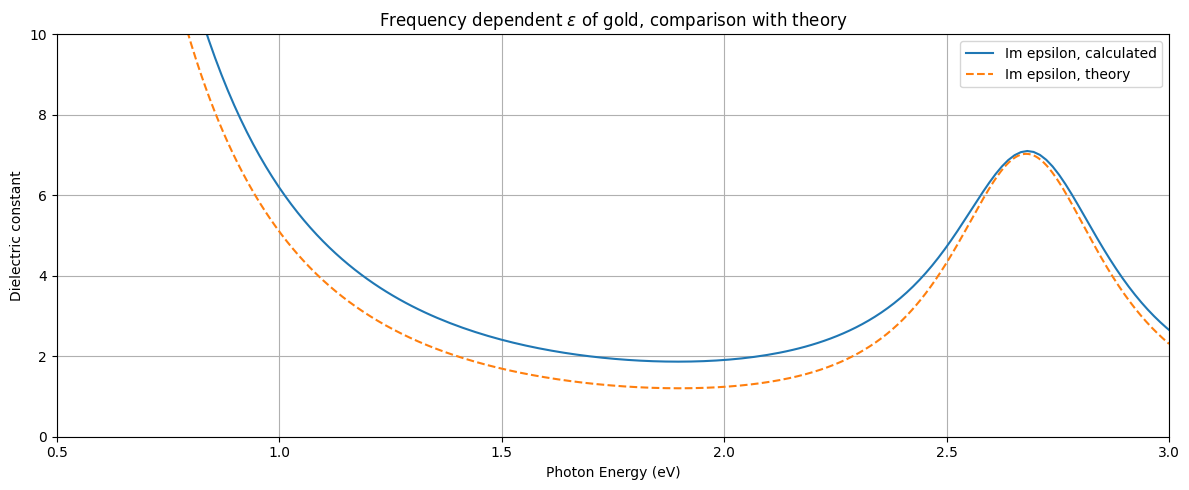

In [60]:
plt.figure(figsize=(12,5))
plt.plot(phot_ev,np.imag(epsilon_calculated),label="Im epsilon, calculated")
plt.plot(phot_ev_theory, np.imag(epsilon_theory), label='Im epsilon, theory',linestyle="--")

plt.xlabel('Photon Energy (eV)')
plt.ylabel('Dielectric constant')
plt.title(r'Frequency dependent $\epsilon$ of gold, comparison with theory')
plt.grid(True)
plt.xlim((0.5,3.0))
plt.ylim((0.0,10.0))
plt.legend()
plt.tight_layout()
plt.show()

## vary dz

In [ ]:
def run_and_compare(dz=10.0, save=False):
    # Grid + time
    L = 60 * 1e4 # A
    Nz = int(L/dz)
    dt = 0.99 * dz / c0       # CFL stability for 1D, ~ 3 fs

    # Source
    src_pos = 10.0 * 1e4
    src_i = int(np.round(src_pos/dz))

    # metal film
    x_0 = L/2.0 # place at center
    thickness = 500.0 # = 50 nm

    metal_cells = int(np.round(thickness / dz))
    metal_center_i = int(np.round(x_0 / dz))
    metal_i0 = metal_center_i - metal_cells // 2
    metal_i1 = metal_i0 + metal_cells

    #probes
    probe_r_pos = x_0 - thickness / 2.0 - 1.0 * 1e4
    probe_t_pos = x_0 + thickness / 2.0 + 1.0 * 1e4
    probe_r_i = int(np.round(probe_r_pos/dz))           # left-side probe (reflected)
    probe_t_i = int(np.round(probe_t_pos/dz))           # right-side probe (transmitted)

    T_estimate = np.abs(src_pos - probe_t_pos) / c0 * 2.0
    T = np.round(T_estimate + 0.005, 3) #ps
    Nt = int(T/dt)

    simulation_params_withfilm = FDTDParams(
        Nz=Nz,
        Nt=Nt,
        dz= dz, # A
        dt=dt,
        src_i=src_i,
        probe_t_i=probe_t_i,
        probe_r_i=probe_r_i,
        metal_i0=metal_i0,
        metal_i1=metal_i1,
        snap_every= 100,  # 0 disables snapshots
    )

    simulation_params_nofilm = FDTDParams(
        Nz=Nz,
        Nt=Nt,
        dz= dz, # A
        dt=dt,
        src_i=src_i,
        probe_t_i=probe_t_i,
        probe_r_i=probe_r_i,
        metal_i0=metal_i0,
        metal_i1=metal_i0, # make metal thickness=0.0
        snap_every= 100,  # 0 disables snapshots
    )

    E0_VA = 0.1 # E0 in V / A
    E0 = E0_VA * 1.7588e7 # in code units
    f0 = 390.0    # THz
    tau = 0.004 * 0.5 # 4 fs ; short pulse
    t0 = 5*tau
    pulse = PulseParams(E0=E0, f0=f0, t0=t0, tau=tau, phase=0.0)

    material = MaterialParamsTD.from_static(
        Nt=simulation_params_withfilm.Nt,
        omega_D=2*np.pi*2113.6, 
        gamma_D=2.0*np.pi*15.92,
        omega_L=2.0*np.pi*650.07, 
        gamma_L=2.0*np.pi*104.86,
        del_eps=1.09, 
        eps_inf=5.9673,
    )

    #run two simulations
    E_t_withfilm, E_r_withfilm, snaps_t_withfilm, snaps_E_withfilm = run_simulation(simulation_params_withfilm, pulse, material)
    E_t_nofilm, E_r_nofilm, snaps_t_nofilm, snaps_E_nofilm = run_simulation(simulation_params_nofilm, pulse, material)

    if save:

        foldername = f"run1_dz{dz}"
        save_simulation_run(
            folder=f"../output/{foldername}/with_film",
            params=simulation_params_withfilm, 
            pulse=pulse,             
            material=material,           
            E_t=E_t_withfilm,
            E_r=E_r_withfilm,
            snaps_t=snaps_t_withfilm,
            snaps_E=snaps_E_withfilm,
        )

        save_simulation_run(
            folder=f"../output/{foldername}/nofilm",
            params=simulation_params_nofilm, 
            pulse=pulse,             
            material=material,           
            E_t=E_t_nofilm,
            E_r=E_r_nofilm,
            snaps_t=snaps_t_nofilm,
            snaps_E=snaps_E_nofilm,
        )

    w_fit, n_fit, k_fit, t_meas_fit, t_model_fit, good = retrieve_nk_from_time_traces(E_transmitted=E_t_withfilm,
                                                                                  E_incident=E_t_nofilm,
                                                                                  t_ax=t_ax,
                                                                                  d=thickness*unit_L)
    
    epsilon_calculated = np.power(n_fit + 1.0j*k_fit, 2.0)
    phot_ev_theory, epsilon_theory = epsilon_analytical_drude_lorentz()

    #plot
    plt.figure(figsize=(12,5))
    plt.plot(phot_ev,np.imag(epsilon_calculated),label="Im epsilon, calculated")
    plt.plot(phot_ev_theory, np.imag(epsilon_theory), label='Im epsilon, theory',linestyle="--")

    plt.xlabel('Photon Energy (eV)')
    plt.ylabel('Dielectric constant')
    plt.title(r'Frequency dependent $\epsilon$ of gold, comparison with theory')
    plt.grid(True)
    plt.xlim((0.5,3.0))
    plt.ylim((0.0,10.0))
    plt.legend()
    plt.tight_layout()
    plt.show()

In [63]:
run_and_compare(dz=5.0,save=True)

Simulation saved to: ../output/run1_dz5.0/with_film
Simulation saved to: ../output/run1_dz5.0/nofilm


ValueError: E_trans, E_inc, and t_ax must have the same shape.

## Peaks

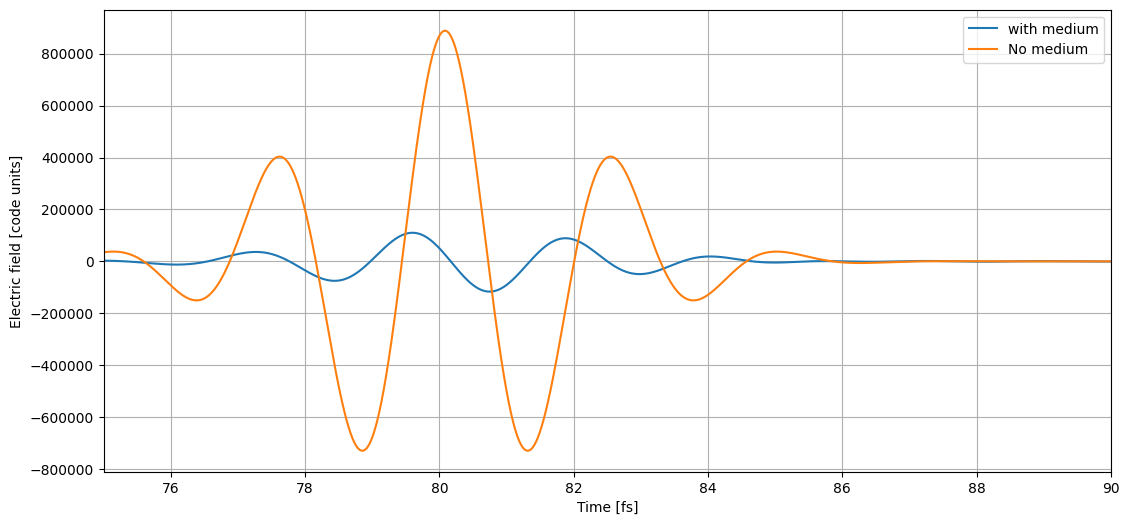

In [ ]:
t_ax = np.linspace(0.0,T,Nt)*1e3

# plot time domain pulses    
# plt.plot(t_ax,Et,label="with medium")
# plt.plot(t_ax,Et_nofilm,label = "No medium")
fig,ax = plt.subplots(figsize=(13,6))
plt.plot(t_ax,Et,label="with medium")
plt.plot(t_ax,Et_nofilm,label = "No medium")
plt.xlabel("Time [fs]")
plt.ylabel("Electric field [code units]")
plt.grid(True)
# plt.ylim((-10,10))
plt.xlim((75,90))
plt.legend()
plt.show()

In [25]:

def find_array_peaks_in_range(
    y,
    label,
    lower,
    upper,
    height=None,
    prominence=None,
    distance=None,
    plot=True
):
    """
    Identify peaks in a 1D numpy array and retain only those within
    a specified index range [lower, upper].

    Parameters
    ----------
    y : np.ndarray
        Input 1D signal array.
    label : str
        Label for plotting.
    lower : int
        Lower index bound (inclusive).
    upper : int
        Upper index bound (inclusive).
    height : float or tuple, optional
        Minimum (and optionally maximum) peak height.
    prominence : float, optional
        Required prominence of peaks.
    distance : int, optional
        Minimum number of samples between neighboring peaks.
    plot : bool
        If True, plots signal with peaks marked.

    Returns
    -------
    peak_indices : np.ndarray
        Filtered peak indices within [lower, upper].
    peak_values : np.ndarray
        Corresponding peak values.
    """

    # --- Validate bounds ---
    if lower < 0 or upper >= len(y):
        raise ValueError("Index bounds must lie within signal length.")

    if lower >= upper:
        raise ValueError("lower must be < upper.")

    # --- Detect all peaks ---
    peak_indices, properties = find_peaks(
        y,
        height=height,
        prominence=prominence,
        distance=distance
    )

    # --- Apply index window filter ---
    mask = (peak_indices >= lower) & (peak_indices <= upper)

    peak_indices = peak_indices[mask]
    peak_values = y[peak_indices]

    # --- Plot ---
    if plot:
        plt.figure(figsize=(13,6))
        plt.plot(y, label=label)
        plt.axvline(lower, linestyle="--")
        plt.axvline(upper, linestyle="--")
        plt.plot(peak_indices, peak_values, "o")
        plt.xlabel("Index")
        plt.ylabel("Signal Value")
        plt.title(f"Detected Peaks in Range [{lower}, {upper}]")
        plt.legend()
        plt.grid(True)
        plt.show()

    return peak_indices, peak_values



In [26]:
# ---------------------------------------------------------
# Example usage
# ---------------------------------------------------------
lower_id = 40000
upper_id = 140000

peak_positions_nofilm, peak_values_nofilm = find_array_peaks_in_range(
    Et_nofilm,
    lower=lower_id,upper=upper_id,
    prominence=0.5,
    distance=20,
    label="no film"
)

# Et = T_probe
peak_positions_transmitted, peak_values_transmitted = find_array_peaks_in_range(
    Et,
    lower=lower_id,upper=upper_id,
    prominence=0.5,
    distance=20,
    label="with film"
)

ValueError: Index bounds must lie within signal length.

In [16]:
peak_positions_nofilm.shape

(128,)

In [17]:
peak_positions_transmitted.shape

(128,)

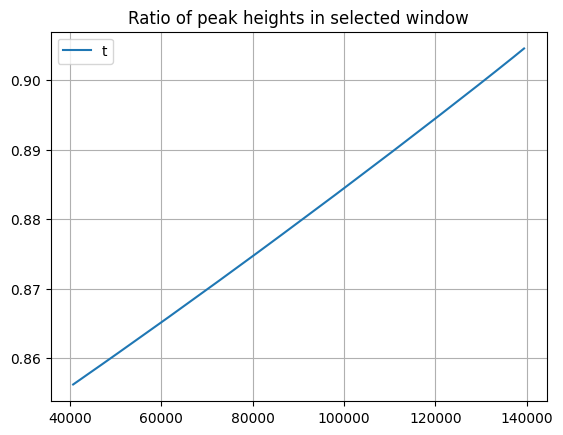

In [18]:
ratio = peak_values_transmitted/peak_values_nofilm

# with the indices of the no film run
plt.plot(peak_positions_nofilm,ratio, label="t")
plt.title("Ratio of peak heights in selected window")
plt.legend()
plt.grid(True)
plt.show()

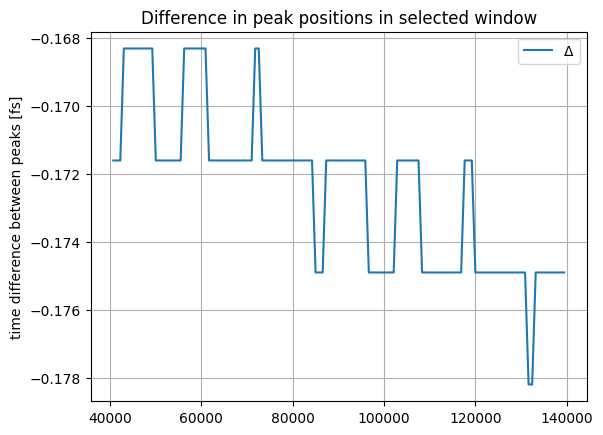

In [19]:
phase_diff = (peak_positions_transmitted - peak_positions_nofilm)*dt*1e3

# with the indices of the no film run
plt.plot(peak_positions_nofilm,phase_diff, label=r"$\Delta$")
plt.title("Difference in peak positions in selected window")
plt.ylabel("time difference between peaks [fs]")
plt.legend()
plt.grid(True)
plt.show()

## Fourier transform

In [32]:
# infer n + jk from analysis
w_arr = freq * 2*np.pi * unit_F
thickness_SI = 500 * unit_L # 50 nm data
c0_SI = 3.0e8
kappa_arr = -1.0 * np.log(np.abs(transmission_coeff)) * c0_SI / (thickness_SI * w_arr)
n_arr_1 = (np.angle(transmission_coeff) + 2*np.pi) * c0_SI / (thickness_SI * w_arr)
n_arr_2 = (np.angle(transmission_coeff) - 2*np.pi) * c0_SI / (thickness_SI * w_arr)
# n_arr = angle_diff

eps_arr_sqrt_1 = n_arr_1 + 1.0j * kappa_arr
eps_arr_1 = np.power(eps_arr_sqrt_1,2)
eps_arr_sqrt_2 = n_arr_2 + 1.0j * kappa_arr
eps_arr_2 = np.power(eps_arr_sqrt_2,2)


/tmp/ipykernel_7843/1429133708.py:5: RuntimeWarning: divide by zero encountered in divide
  kappa_arr = -1.0 * np.log(np.abs(transmission_coeff)) * c0_SI / (thickness_SI * w_arr)
/tmp/ipykernel_7843/1429133708.py:6: RuntimeWarning: divide by zero encountered in divide
  n_arr_1 = (np.angle(transmission_coeff) + 2*np.pi) * c0_SI / (thickness_SI * w_arr)
/tmp/ipykernel_7843/1429133708.py:7: RuntimeWarning: divide by zero encountered in divide
  n_arr_2 = (np.angle(transmission_coeff) - 2*np.pi) * c0_SI / (thickness_SI * w_arr)
/tmp/ipykernel_7843/1429133708.py:10: RuntimeWarning: invalid value encountered in multiply
  eps_arr_sqrt_1 = n_arr_1 + 1.0j * kappa_arr
/tmp/ipykernel_7843/1429133708.py:12: RuntimeWarning: invalid value encountered in multiply
  eps_arr_sqrt_2 = n_arr_2 + 1.0j * kappa_arr


In [35]:
def transmission_coeff_analytical(n,k,d,w):

    wavelength = (2*np.pi*c0_SI)/w
    u_2 = n
    v_2 = k

    u_2_sq = u_2**2.0
    v_2_sq = v_2**2.0

    tau_12_sq = 4.0 / ((1.0+u_2)**2.0 + v_2_sq)
    tau_23_sq = 4.0 * (u_2_sq + v_2_sq) / ((1.0+u_2)**2.0 + v_2_sq)
    chi_12 = np.arctan2(-1.0*v_2, (1.0+u_2))
    chi_23 = np.arctan2(v_2, (u_2_sq + v_2_sq + u_2))

    rho_sq = ((1.0-u_2)**2.0 + v_2_sq) / ((1.0+u_2)**2.0 + v_2_sq)
    phi = np.arctan((2.0 * v_2)/(u_2_sq + v_2_sq - 1.0))
    eta = 2*np.pi*d/wavelength

    exp_2v_2_eta = np.exp(2.0*v_2*eta)
    exp_2v_2_eta_inv = 1.0 / exp_2v_2_eta
    cosine_factor = np.cos(2.0*phi + 2.0*u_2*eta)

    arctan_delta_t_rhs = np.arctan2((exp_2v_2_eta*np.sin(2.0*u_2*eta) - rho_sq*np.sin(2.0*phi)), (exp_2v_2_eta*np.cos(2.0*u_2*eta) + rho_sq*np.cos(2.0*phi)))
    delta_t = arctan_delta_t_rhs + chi_12 + chi_23 - u_2*eta
    phase = np.exp(1.0j*delta_t)

    denom = 1.0 + (rho_sq*exp_2v_2_eta_inv)**2.0 + 2.0*rho_sq*exp_2v_2_eta_inv*cosine_factor
    t_sq = (tau_12_sq * tau_23_sq * exp_2v_2_eta_inv) / denom

    return np.sqrt(t_sq)*phase

In [36]:
def transmission_coeff_simple(n,k,d,w):
    t_abs = np.exp(-1.0*k*d*w/c0_SI)
    phase = np.exp(1.0j*(n-1.0)*d*w/c0_SI)

    return t_abs*phase

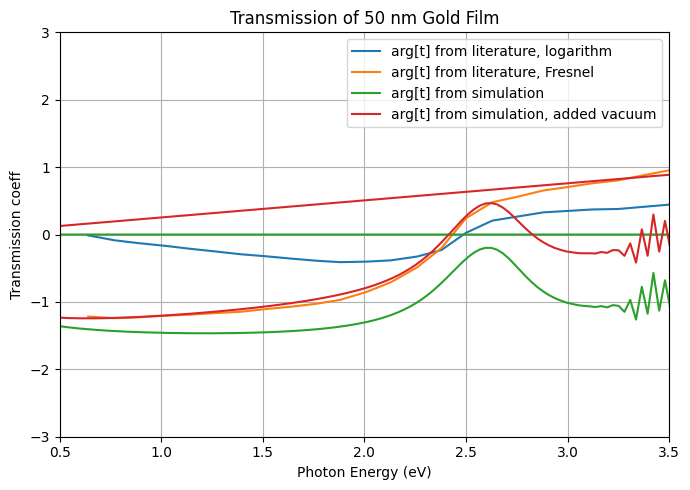

In [41]:
# -----------------------------
# Transmission of 50 nm gold film
# Vacuum–film–vacuum
# -----------------------------
d = 50e-9  # thickness (m)

# Convert photon energy to angular frequency
omega = 2 * np.pi * E_eV / h_eVs
k0 = omega / c0

t_arr_analytical = transmission_coeff_analytical(n_gold,k_gold,d,omega)
t_arr_simple = transmission_coeff_simple(n_gold,k_gold,d,omega)

T_abs_analytical = np.abs(t_arr_analytical)
T_phi_analytical = np.angle(t_arr_analytical)

delta_phi = d*(2*np.pi*freq*unit_F)/c0_SI

plt.figure(figsize=(7,5))
plt.plot(E_eV, np.angle(t_arr_simple),label="arg[t] from literature, logarithm")
plt.plot(E_eV, T_phi_analytical, label="arg[t] from literature, Fresnel")
plt.plot(phot_ev,np.angle(transmission_coeff),label="arg[t] from simulation")
plt.plot(phot_ev,np.angle(transmission_coeff)+delta_phi,label="arg[t] from simulation, added vacuum")

# plt.plot(E_eV, T_abs_analytical**2.0,label="|t|")
plt.xlabel('Photon Energy (eV)')
plt.ylabel('Transmission coeff')
plt.title('Transmission of 50 nm Gold Film')
plt.grid(True)
plt.xlim((0.5,3.5))
plt.ylim((-3,3))
plt.legend()
plt.tight_layout()
plt.show()

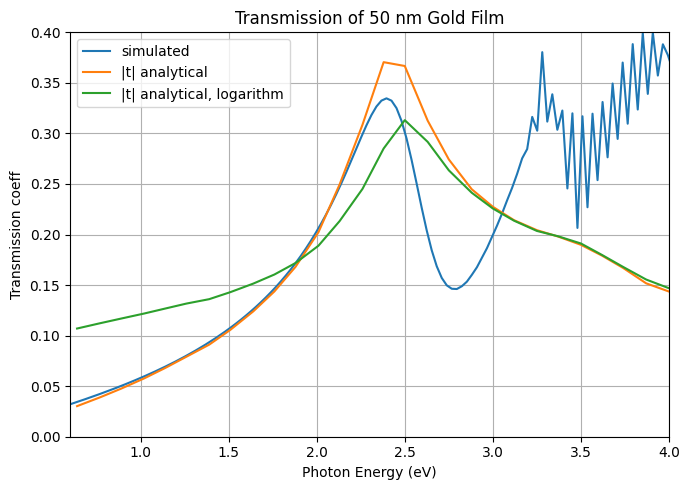

In [38]:
plt.figure(figsize=(7,5))
plt.plot(phot_ev, np.abs(transmission_coeff), label="simulated")
plt.plot(E_eV, T_abs_analytical,label="|t| analytical")
plt.plot(E_eV, np.abs(t_arr_simple),label="|t| analytical, logarithm")
plt.xlabel('Photon Energy (eV)')
plt.ylabel('Transmission coeff')
plt.title('Transmission of 50 nm Gold Film')
plt.grid(True)
plt.xlim((0.6,4.0))
plt.ylim((0.0,0.4))
plt.legend()
plt.tight_layout()
plt.show()